**(a)**

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from collections import Counter

#random seed used for measurement measurment 
np.random.seed(42)


def one_qubit_basis():
    #One qubits basis states, computational basis 
    zero = np.array([1,0])
    one = np.array([0,1])
    return zero, one


zero, one = one_qubit_basis()

#Pauli matrices 
I = np.eye(2) #identity 
Z = np.array([[1.0, 0.0], [0.0, -1.0]]) #Pauli Z
X = np.array([[0.0, 1.0], [1.0, 0.0]]) #Pauli X
Y = np.array([[0.0, -1.0j], [1.0j, 0.0]]) #Pauli Y 

#Hadamard and Phase 
H = 1/np.sqrt(2) * np.array([[1, 1], [1, -1]]) #Hadamard 
S = np.array([[1, 0], [0, 1j]]) #Phase 


#put all gates in list 
gates = [("I",I), ("Z",Z), ("X",X), ("Y",Y), ("Hadamard, H", H), ("Phase gate", S)]

#Function for applying gate to a state 
def apply_gate(gate, state):
    return gate @ state 

#Format digits
def format_state(state):
    return np.round(state, 3)


#collect results of applying gates  
data = []


def apply_multiple_gates(gates):
    #loop through the gates and apply to comp.basis for one qubit
    for name, gate in gates: 
        #apply gate 
        result_zero = apply_gate(gate, zero)
        result_one = apply_gate(gate, one)
        
        #append result to data
        data.append({"Gate": name, 
                    "Gate @ |0> = [1, 0]": format_state(result_zero),
                    "Gate @ |1> = [0, 1]": format_state(result_one)})


    #print a nice table using pandas 
    df = pd.DataFrame(data)

    # Improve display formatting
    pd.set_option("display.max_colwidth", None)

    print(df.to_string(index=False))


def bell_states():
    #Bell states 
    Phi_plus = (1/np.sqrt(2)) * (np.kron(zero, zero) + np.kron(one, one)) 
    Phi_min = (1/np.sqrt(2)) * (np.kron(zero, zero) - np.kron(one, one))
    Psi_plus = (1/np.sqrt(2)) * (np.kron(zero, one) + np.kron(one, zero))
    Psi_min = (1/np.sqrt(2)) * (np.kron(zero, one) - np.kron(one, zero))

    return Phi_plus, Phi_min, Psi_plus, Psi_min

Phi_plus, Phi_min, Psi_plus, Psi_min = bell_states()

#One qubit projectors 
P0 = np.outer(zero, zero) #|0><0|
P1 = np.outer(one, one) # |1><1| 



def cnot_operator(control):
    # Build CNOT with control qubit index (0 or 1)
    if control == 0:
        return np.kron(P0, I) + np.kron(P1, X)
    elif control == 1:
        return np.kron(I, P0) + np.kron(X, P1)
    else:
        raise ValueError("control must be 0 or 1")




def hadamard_which_qubit(qubit_index): 
    if qubit_index == 0: 
        H_on_two = np.kron(H, I)
    else:
        H_on_two = np.kron(I, H)
    return H_on_two


#apply Hadamard followed by a CNOT on Bell state
def Hadamamard_and_CNOT(qubit_index_H, qubit_index_CNOT, state): 
    """
    - qubit_index: index for which qubit to apply Hadamard 
    - param state: the quantum state 
    """
    H = hadamard_which_qubit(qubit_index_H)
    H_state = H @ state
    result = cnot_operator(qubit_index_CNOT) @ H_state
    return result





def measurement(state):
    """
    Measurement in computational basis 
    Arguments: - state, state to be measured 
    """

    #probabilities for qubit0 
    probs0 = np.array([np.sum(np.abs(state[[0,1]])**2), np.sum(np.abs(state[[2,3]])**2)])
    outcome0 = np.random.choice([0,1], p=probs0)
    if outcome0 == 0:
        collapsed = state.copy()
        collapsed[2:] = 0  #amplitudes set to zero 
    else: 
        collapsed = state.copy()
        collapsed[0:2] = 0 

    #normalize 
    norm = np.linalg.norm(collapsed)
    collapsed = collapsed/norm

    #probabilities for qubit 1
    probs1 = np.array([np.sum(np.abs(collapsed[[0,2]])**2), np.sum(np.abs(collapsed[[1,3]])**2)])
    outcome1 = np.random.choice([0,1], p = probs1)

    return outcome0, outcome1 

        
#created with chatGPT for getting statistics and plotting them 
def simulate_measurements(state, n_shots=10000):
    """
    Measure both qubits sequentially n_shots times.
    Returns:
        - counts dictionary
        - empirical probabilities
        - mean and std per qubit
    """
    outcomes_q0 = []
    outcomes_q1 = []
    
    for _ in range(n_shots):
        o0, o1 = measurement(state)
        outcomes_q0.append(o0)
        outcomes_q1.append(o1)
    
    # Counts for each joint outcome
    joint_counts = Counter([f"{o0}{o1}" for o0,o1 in zip(outcomes_q0, outcomes_q1)])
    
    # Empirical probabilities
    joint_probs = {k: v/n_shots for k,v in joint_counts.items()}
    
    # Mean and standard deviation for each qubit
    mean_q0 = np.mean(outcomes_q0)
    std_q0  = np.std(outcomes_q0)
    
    mean_q1 = np.mean(outcomes_q1)
    std_q1  = np.std(outcomes_q1)
    
    return {
        "joint_counts": joint_counts,
        "joint_probs": joint_probs,
        "mean_q0": mean_q0,
        "std_q0": std_q0,
        "mean_q1": mean_q1,
        "std_q1": std_q1
    }





# Suppose Phi_plus is your initial state
final_state = Hadamamard_and_CNOT(1, 1, Psi_min)  # Apply H on qubit 0, CNOT with control 0
results = simulate_measurements(final_state, n_shots=100000)

print("Joint counts:", results["joint_counts"])
print("Joint probabilities:", results["joint_probs"])
print(f"Qubit 0: mean={results['mean_q0']:.9f}, std={results['std_q0']:.3f}")
print(f"Qubit 1: mean={results['mean_q1']:.9f}, std={results['std_q1']:.3f}")
amps = final_state
probs_q0 = [np.sum(np.abs(amps[[0,1]])**2), np.sum(np.abs(amps[[2,3]])**2)]
probs_q1 = [np.sum(np.abs(amps[[0,2]])**2), np.sum(np.abs(amps[[1,3]])**2)]



#create density matrix: 
def create_density(state):
    return np.outer(state, np.conj(state))

#trace out second qubit 
def partial_trace(rho, dims, subsystem):
    """
    Compute partial trace over subsystem
    Arguments - rho, density matrix 
              - dims, tuple of dimensions of subsystem A and B 
              - subsystem, which subsystem to trace out, 0 traces out qubit 0, 1 traces out qubit 1

    Returns:  - returns reduced density matrix 
    """
    dA, dB = dims #dimensions of subsystem A and B 
    rho_reshaped = rho.reshape(dA, dB, dA, dB) #reshape rho 

    if subsystem == 0: 
        #Trace out A, keep B 
        rho_B = np.einsum('ikjk->ij', rho_reshaped) #sum over A axes 
        return rho_B
    elif subsystem == 1: 
        #trace out B, keep A
        rho_A = np.einsum('ijik->jk', rho_reshaped) #sum over B axes 
        return rho_A
    

rho = create_density(Phi_plus)
dims = (2,2) #dimensions of subsystem A and B 
rho_B = partial_trace(rho, dims, 0)
rho_A = partial_trace(rho, dims, 1)

def von_neumann_entropy(rho):
    #obtain eigenvalues of density matrix 
    eigenvalues = np.linalg.eigvalsh(rho)
    eigenvalues = eigenvalues[eigenvalues > 1e-12] #avoid 0*log(0), when lambda_i = 0, no contribution to entropy. 
    S = -np.sum(eigenvalues * np.log2(eigenvalues))
    #compute von neumann entropy 
    return S


Joint counts: Counter({'11': 25083, '01': 25076, '10': 24990, '00': 24851})
Joint probabilities: {'01': 0.25076, '11': 0.25083, '00': 0.24851, '10': 0.2499}
Qubit 0: mean=0.500730000, std=0.500
Qubit 1: mean=0.501590000, std=0.500


**(b)**

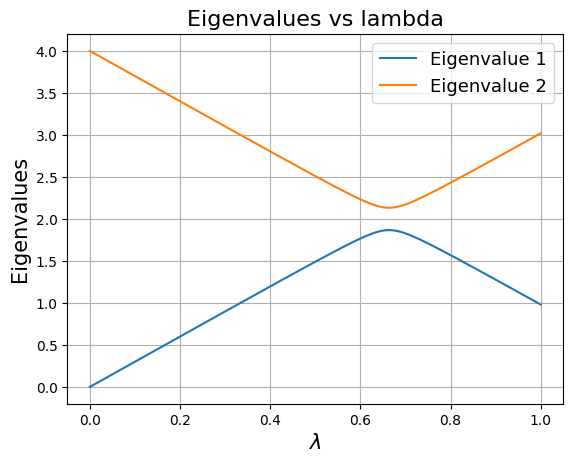

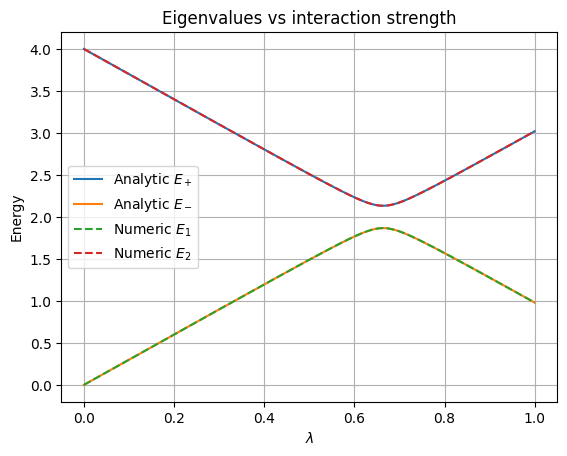

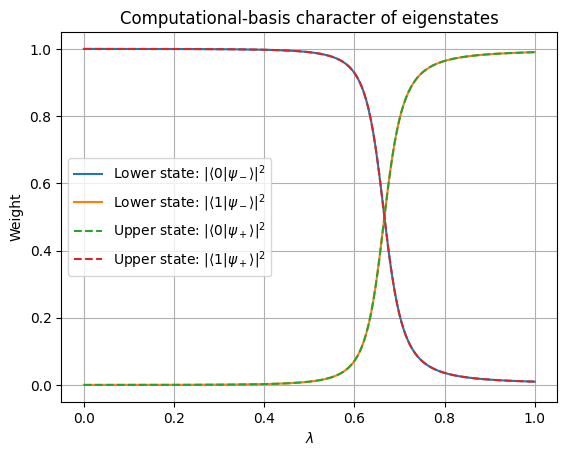

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

# Defining variables and setting up the Hamiltonian

E1 = 0
E2 = 4
V11 = 3
V22 = -V11
V12 = V21 = 0.2



"""
Is it accepted to solve the Hamiltonian H_I when written as such? 
We havent written it in terms of sigma matrices. 
"""

def hamiltonian(l=0.0):
    H_0 = np.array([[E1, 0], [0, E2]])
    H_i = np.array([[V11, V21], [V12, V22]])    
    return np.array(H_0 + l*H_i)

real = [[3, 0.2], [0.2, -3]]

N = 500
lams = np.linspace(0, 1, N)

eigvals = np.zeros((N, 2))

for i, lam in enumerate(lams):
    w, v = np.linalg.eigh(hamiltonian(lam))
    eigvals[i, :] = w

# Plot
plt.plot(lams, eigvals[:, 0], label="Eigenvalue 1")
plt.plot(lams, eigvals[:, 1], label="Eigenvalue 2")

plt.xlabel(r"$\lambda$", fontsize=15)
plt.ylabel("Eigenvalues", fontsize=15)
plt.title("Eigenvalues vs lambda",fontsize=16)
plt.legend(fontsize=13)
plt.grid(True)
plt.show()

import numpy as np
import matplotlib.pyplot as plt

# Parameters from the problem
E1 = 0
E2 = 4
V11 = 3
V22 = -3
V12 = 0.2

# Derived parameters
epsilon = (E1 + E2) / 2
Omega = (E1 - E2) / 2
c = (V11 + V22) / 2
omega_z = (V11 - V22) / 2
omega_x = V12

# Pauli matrices
sigma_x = np.array([[0,1],[1,0]])
sigma_z = np.array([[1,0],[0,-1]])
I = np.eye(2)

# Lambda values
lam = np.linspace(0,1,200)

E_plus = []
E_minus = []
E_num1 = []
E_num2 = []

for l in lam:

    # analytic eigenvalues
    term = np.sqrt((Omega + l*omega_z)**2 + (l*omega_x)**2)
    E_plus.append((epsilon + l*c) + term)
    E_minus.append((epsilon + l*c) - term)

    # build Hamiltonian and diagonalize numerically
    H = (epsilon + l*c)*I + (Omega + l*omega_z)*sigma_z + (l*omega_x)*sigma_x
    evals = np.linalg.eigvalsh(H)

    E_num1.append(evals[0])
    E_num2.append(evals[1])

# Plot
plt.plot(lam, E_plus, label="Analytic $E_+$")
plt.plot(lam, E_minus, label="Analytic $E_-$")

plt.plot(lam, E_num1, '--', label="Numeric $E_1$")
plt.plot(lam, E_num2, '--', label="Numeric $E_2$")

plt.xlabel(r"$\lambda$")
plt.ylabel("Energy")
plt.title("Eigenvalues vs interaction strength")
plt.legend()
plt.grid()
plt.show()






import numpy as np
import matplotlib.pyplot as plt

# Parameters
E1 = 0
E2 = 4
V11 = 3
V22 = -3
V12 = 0.2

epsilon = (E1 + E2) / 2
Omega = (E1 - E2) / 2
c = (V11 + V22) / 2
omega_z = (V11 - V22) / 2
omega_x = V12

sigma_x = np.array([[0, 1], [1, 0]], dtype=float)
sigma_z = np.array([[1, 0], [0, -1]], dtype=float)
I = np.eye(2)

lam_vals = np.linspace(0, 1, 400)

# Store |0>- and |1>-weights for lower and upper eigenstates
lower_0 = []
lower_1 = []
upper_0 = []
upper_1 = []

for lam in lam_vals:
    H = (epsilon + lam*c)*I + (Omega + lam*omega_z)*sigma_z + (lam*omega_x)*sigma_x

    # eigvalsh/eigh sorts eigenvalues ascending
    evals, evecs = np.linalg.eigh(H)

    v_lower = evecs[:, 0]
    v_upper = evecs[:, 1]

    lower_0.append(abs(v_lower[0])**2)
    lower_1.append(abs(v_lower[1])**2)
    upper_0.append(abs(v_upper[0])**2)
    upper_1.append(abs(v_upper[1])**2)

plt.plot(lam_vals, lower_0, label=r"Lower state: $|\langle 0|\psi_-\rangle|^2$")
plt.plot(lam_vals, lower_1, label=r"Lower state: $|\langle 1|\psi_-\rangle|^2$")
plt.plot(lam_vals, upper_0, "--", label=r"Upper state: $|\langle 0|\psi_+\rangle|^2$")
plt.plot(lam_vals, upper_1, "--", label=r"Upper state: $|\langle 1|\psi_+\rangle|^2$")

plt.xlabel(r"$\lambda$")
plt.ylabel("Weight")
plt.title("Computational-basis character of eigenstates")
plt.legend()
plt.grid()
plt.show()

**(c)**

Saved: vqe_comparison_e3.pdf


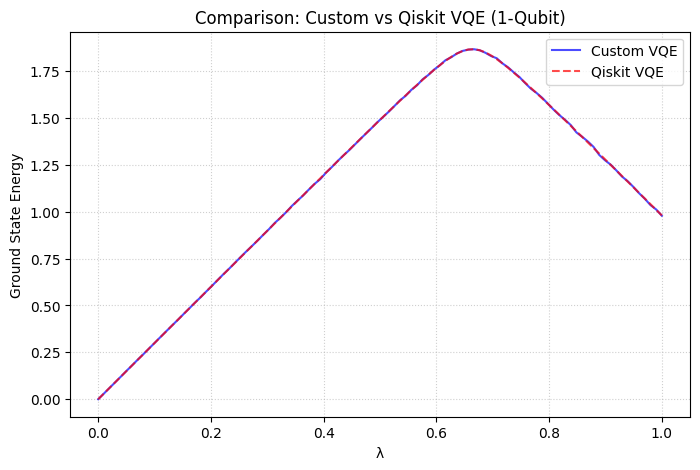

In [3]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_algorithms.optimizers import ADAM
import warnings
warnings.filterwarnings('ignore')
import exercise1 as e1
import exercise2 as e2
import exercise4 as e4

# Set random seed for reproducibility
np.random.seed(42)





"""
VQE plan: 
1. Ansatz. 

2. Measure E(theta) = <psi(theta)|H|psi(theta)> 


3.optimize, find theta that minimizes E(theta)

4. result ground state energy and wavefunction 
"""


#Gates 
X = e1.X 
Z = e1.Z 
I = e1.I 
H = e1.H
S = e1.S 


#parameters 


#Hamiltonian, H = H0 + lambda*HI. H_I =  cI + w_z Z + w_x X 
c = (e2.V11 + e2.V22)/2
w_z = (e2.V11 - e2.V22)/2 
w_x = e2.V12
eps = (e2.E1+e2.E2)/2
omega = (e2.E1-e2.E2)/2


H_0 = eps*I + omega*Z 
H_I = c*I + w_z*Z + w_x*X



#defining quantum rotation gates 
def Rx(theta): 
    "rotation about x-axis of angle theta"
    Rx = np.array([[np.cos(theta/2), -1j*np.sin(theta/2)],
                   [-1j*np.sin(theta/2), np.cos(theta/2)]], dtype=complex)
    return Rx

def Ry(theta): 
    "Rotation about y-axis of angle theta"
    Ry = np.array([[np.cos(theta/2), -np.sin(theta/2)], 
                   [np.sin(theta/2), np.cos(theta/2)]], dtype=complex)
    return Ry

def Rz(theta): 
    "Rotation about z-axis of angle theta"
    Rz = np.array([[np.exp(-1j*theta/2), 0], [0, np.exp(1j*theta/2)]], dtype=complex)

    return Rz

def ansatz_state(angles): 
    """
    Ansatz state 
    """
    U = Rz(angles[2])@Ry(angles[1])@Rz(angles[0]) #standard ansatz U = RzRyRz, I shall try with RxRyRx as well 
    state = U @ np.array([1,0])
    return state

def measure_Z(state, shots): 
    """
    Measures state in Z basis 
    Arguments: - State, state to be measured, np.array
               - shots, number of shots (measurements)
    """
    
    #probabilities 
    probs = np.abs(state)**2
   

    #Do measurements and count the number of times we measure 0 and 1
    n0 = np.random.binomial(shots, probs[0])
    n1 = shots - n0

    mean = (n0 - n1)/shots
    counts = (n0, n1)

    return mean, counts


def measure_X(state, shots): 
    """
    Rotate X to Z with Hadamard to measure in X 
    Arguments: - state, state to be measured 
               - shots, number of measurements/shots 
    """

    #rotate state 
    rotated_state = H @ state 

    #perform measurment in Z basis after rotation 
    mean, counts = measure_Z(rotated_state, shots)

    return mean, counts 

def measure_Y(state, shots): 
    """
    Rotate Y to Z with Hadamard gate and dagger of phase gate to measure in Y
    Arguments: - state, state to be measured 
               - shots, number of measurements/shots 
    """

    #rotate state with phase gate and hadamard gate 
    rotated_state = H @ (S.conj().T @ state) 

    #perform measurement in Z basis after rotation 

    mean, counts = measure_Z(rotated_state, shots)

    return mean, counts 



def measure_energy(state, shots, coeffs): 
    """
    Measure energy of the Hamiltonian when it is written as sum of Pauli gates
    Arguments: - state, state to be measured 
               - shots, number of shots 
               - coeffs, dictionary containing the coefficients infront the Pauli-terms in Hamiltonian
    """

    #measure I 
    E_I = coeffs["I"] 

    #measure Z 
    measure_z, _ = measure_Z(state, shots)
    E_Z = coeffs["Z"] * measure_z

    #Measure X 
    measure_x, _ = measure_X(state, shots)
    E_X = coeffs["X"] * measure_x

    E = E_I + E_Z + E_X

    return E 




def gradient_energy(params, shots, coeffs):
    """
    Computes the gradient of the energy with parameter-shift rule 
    Arguments: - params, angles used for the rotation gates
               - shots, number of shots
               - coeffs, coefficients infront of Pauli gates in Hamiltonian
    """
    #angle used in parameter-shift 
    shift = np.pi/2 


    gradients = []
    for i in range(len(params)):
        params_plus = params.copy()
        params_plus[i] += shift 

        params_min = params.copy()
        params_min[i] -= shift
        
        #states
        state_plus = ansatz_state(params_plus)
        state_min = ansatz_state(params_min)

        #energies 
        E_plus = measure_energy(state_plus, shots, coeffs)
        E_min = measure_energy(state_min, shots, coeffs)


        #compute gradient
        gradients.append((E_plus - E_min)/2)

    return gradients

class AdamOptimizerVQE: 
    """
    Minimal gradient descent used in VQE 
    """
    def __init__(self, shots, coeffs):
        self.shots = shots 
        self.coeffs = coeffs 

    #compute energy
    def energy(self, params): 
        state = ansatz_state(params)
        return measure_energy(state, self.shots, self.coeffs)
    
    #compute gradient using parameter-shift rule 
    def gradient(self, params, shift = np.pi/2):
        params = np.asarray(params, dtype=float)
        grads = np.zeros_like(params)
        for i in range(len(params)):
            p_plus = params.copy()
            p_min = params.copy()
            p_plus[i] += shift 
            p_min[i] -= shift 

            e_plus = self.energy(p_plus)
            e_min = self.energy(p_min)
            grads[i] = (e_plus-e_min)/2
        return grads
    
    #Optimiziation part, Adam Optimizer 
    def optimize_Adam(self, params, lr=0.1, beta_1 = 0.9, beta_2 = 0.99, eps = 1e-9, maxiter = 500):
        angles = np.asarray(params, dtype=float).copy()
        m = np.zeros_like(angles)
        v = np.zeros_like(angles)
        history = []
        for i in range(1, maxiter + 1):
            g = self.gradient(angles)
            m = beta_1 * m + (1 - beta_1) * g
            v = beta_2 * v + (1 - beta_2) * (g * g)
            m_hat = m/(1-beta_1**i)
            v_hat = v/(1-beta_2**i)
            angles = angles - lr * m_hat/(np.sqrt(v_hat) + eps)
            history.append(self.energy(angles))

        return {"angles":angles, "energy":history[-1]}

    


    


def find_lowest_eigenvalues():
    params = np.random.uniform(0, 2*np.pi, 3)
    shots = 100

    #Parameter Lambda infront of H_I
    lmbda = np.linspace(0,1,500)
    energies = []
    counter = 0
    for lam in lmbda:
        print(counter)
        #coefficients infront of Pauli matrices, for H_0 and H_1 
        coeffs_both = {"I": eps+c*lam, "Z": omega + w_z*lam, "X":w_x*lam}


        vqe = AdamOptimizerVQE(shots, coeffs_both)
        values = vqe.optimize_Adam(params)

        energies.append(values["energy"])
        counter += 1
        

    plt.plot(lmbda, energies)
    plt.xlabel("λ")
    plt.ylabel("Ground state energy")
    plt.show()

        


#Qiskit version 

def compare_custom_and_qiskit_e3(N=100):
    from qiskit.circuit import QuantumCircuit, ParameterVector
    from qiskit.quantum_info import SparsePauliOp
    from qiskit.primitives import StatevectorEstimator as Estimator
    from qiskit_algorithms import VQE
    from qiskit_algorithms.optimizers import ADAM
    import exercise2 as e2
    import numpy as np
    import matplotlib.pyplot as plt

    c = (e2.V11 + e2.V22) / 2
    w_z = (e2.V11 - e2.V22) / 2 
    w_x = e2.V12
    eps = (e2.E1 + e2.E2) / 2
    omega = (e2.E1 - e2.E2) / 2

    params_vec = ParameterVector("theta", 3)
    qc = QuantumCircuit(1)
    qc.rz(params_vec[0], 0)
    qc.ry(params_vec[1], 0)
    qc.rz(params_vec[2], 0)

    estimator = Estimator()
    qiskit_optimizer = ADAM(maxiter=500, lr=0.1)

    lmbda = np.linspace(0, 1, N)
    custom_energies = []
    qiskit_energies = []
    

    init_angles = np.random.uniform(0, 2*np.pi, 3)
    
    for count, lam in enumerate(lmbda):
            
  
        coeffs_both = {"I": eps + c*lam, "Z": omega + w_z*lam, "X": w_x*lam}
        

        vqe_custom = AdamOptimizerVQE(shots=5000, coeffs=coeffs_both)
        res_custom = vqe_custom.optimize_Adam(init_angles)
        custom_energies.append(res_custom["energy"])
        

        H = SparsePauliOp.from_list([
            ("I", coeffs_both["I"]), 
            ("Z", coeffs_both["Z"]), 
            ("X", coeffs_both["X"])
        ])
        
        vqe_q = VQE(estimator, qc, qiskit_optimizer, initial_point=init_angles)
        res_q = vqe_q.compute_minimum_eigenvalue(H)
        qiskit_energies.append(res_q.eigenvalue.real)


    plt.figure(figsize=(8, 5))
    plt.plot(lmbda, custom_energies, 'b-', label="Custom VQE", alpha=0.7)
    plt.plot(lmbda, qiskit_energies, 'r--', label="Qiskit VQE", alpha=0.7)
    
    plt.xlabel("λ")
    plt.ylabel("Ground State Energy")
    plt.title("Comparison: Custom vs Qiskit VQE (1-Qubit)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.savefig("vqe_comparison_e3.pdf", bbox_inches="tight")
    print("Saved: vqe_comparison_e3.pdf")

if __name__ == "__main__":
    compare_custom_and_qiskit_e3(100)

**(d)**

In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import exercise1 as e1


#define two-qubit Pauli gates 
II = np.kron(e1.I, e1.I)
IZ = np.kron(e1.I, e1.Z)
ZI = np.kron(e1.Z, e1.I)
ZZ = np.kron(e1.Z, e1.Z)
XX = np.kron(e1.X, e1.X)
YY = np.kron(e1.Y, e1.Y)


#parameters 
eps_00 = 0.0 
eps_11 = 2.5
eps_22 = 6.5 
eps_33 = 7.0
Hx = 2.0
Hz = 3.0


def construct_Hamiltonian(eps_00, eps_11, eps_22, eps_33, Hx, Hz, lam):
    """
    Construct Hamiltonian as sum of Pauli matrices 
    Argument: lam, interaction strength parameter
    """
    #Write Hamiltonian as sum of Pauli operators, coefficients are defined 
    alpha = (1/4)*(eps_00+eps_11+eps_22+eps_33)
    beta = (1/4)*(eps_00+eps_11-eps_22-eps_33)
    gamma = (1/4)*(eps_00-eps_11+eps_22-eps_33)
    delta = (1/4)*(eps_00-eps_11-eps_22+eps_33)
    #Hamiltonian, H0, HI and total
    H_0 = alpha*II + beta*ZI + gamma*IZ + delta*ZZ
    H_I = Hx * XX + Hz * ZZ
    #Full Hamiltonian
    Hamiltonian = H_0 + lam*H_I
    #print(Hamiltonian)
    coeffs = {"I":alpha, "ZI":beta, "IZ":gamma, "ZZ":delta+lam*Hz, "XX":lam*Hx}
    return Hamiltonian, coeffs 

def construct_comp_basis():
    zero_zero = np.array([1,0,0,0])
    zero_one = np.array([0,1,0,0])
    one_zero = np.array([0,0,1,0])
    one_one = np.array([0,0,0,1])
    return zero_zero, zero_one, one_zero, one_one


def compute_eigvals(H):
    """
    Computes the eigenvalues of Hamiltonian 
    
    Argument: -  H, Hamiltonian of system 
    """
    eigvals = np.linalg.eigvalsh(H)
    return eigvals



def multiple_lmbda(N):
    """
    Computes the eigenvalues for different values of parameter strength lmbda 
    
    Arguments: - N, number of different lmbda values to compute eigenvalues for
    """
    lmbda = np.linspace(0,1,N)
    eigvals = np.zeros((N,4)) #empty to hold eigvals later 
    for i, lam in enumerate(lmbda): 
        H, _ = construct_Hamiltonian(eps_00, eps_11, eps_22, eps_33, Hx, Hz, lam)
        eigvals_lam = compute_eigvals(H)
        eigvals[i,:] = eigvals_lam

    return lmbda, eigvals


def compute_entanglement(N, dims, subsystem):
    """
    Computes entanglement for two-qubit system as function of interaction strength lambda

    Arguments: - dims, dimensions of subsystems, tuple
               - subsystem, which subsystem to trace out 
    """
    lmbda = np.linspace(0,1,N)
    entropies = np.zeros_like(lmbda)
    for i,lam in enumerate(lmbda): 
        #construct Hamiltonian and obtain eigenstates 
        H, _= construct_Hamiltonian(lam)
        _, eigvecs = np.linalg.eigh(H)
        #get lowest energy state and compute its density matrix
        lowest_state = eigvecs[:,0] 
        rho = e1.create_density(lowest_state)
        #Take partial trace of qubit 1
        reduced_rho = e1.partial_trace(rho, dims, subsystem = subsystem)
        #Compute Von Neumann entropy 
        entropy = e1.von_neumann_entropy(reduced_rho)
        entropies[i] = entropy
    return lmbda, entropies 



def plot_entropy_vs_lmbda():
    lmbda, entropies = compute_entanglement(N=500, dims=(2,2), subsystem=1)
  

    plt.plot(lmbda, entropies)
    plt.xlabel(r"$\lambda$", fontsize = 14)
    plt.ylabel("Von Neumann entropy", fontsize = 14)
    plt.title("Interaction strengt lambda vs Entropy")
    plt.grid(True)
    plt.show()


def plot_lmbda_vs_eigvals():
    lmbda, eigvals = multiple_lmbda(N=500)

    plt.plot(lmbda, eigvals[:, 0], label="Eigenvalue 1")
    plt.plot(lmbda, eigvals[:, 1], label="Eigenvalue 2")
    plt.plot(lmbda, eigvals[:, 2], label="Eigenvalue 3")
    plt.plot(lmbda, eigvals[:, 3], label="Eigenvalue 4")

    plt.xlabel(r"$\lambda$", fontsize=15)
    plt.ylabel("Eigenvalues", fontsize=15)
    plt.title("Eigenvalues vs lambda",fontsize=16)
    plt.legend(fontsize=13)
    plt.grid(True)
    plt.show()


plot_lmbda_vs_eigvals()

**(e)**

Comparison plot saved successfully as vqe_comparison_e5.pdf!


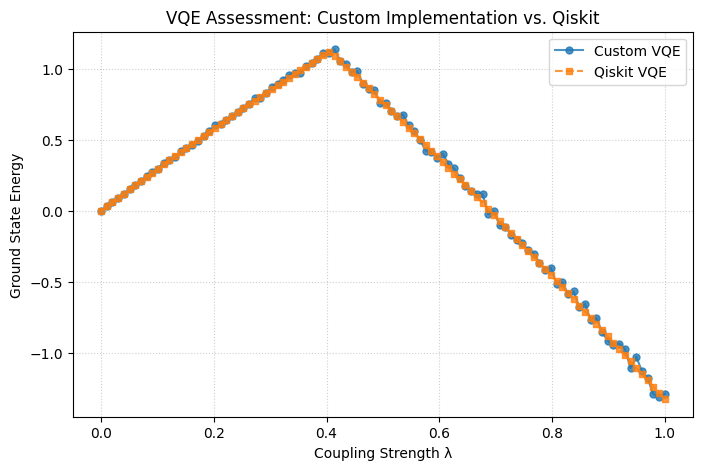

In [4]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_algorithms.optimizers import ADAM
warnings.filterwarnings('ignore')
import exercise1 as e1
import exercise3 as e3
import exercise4 as e4


"""
Here we must have Hamiltonian coefficients as well, but I dont understand the lambda part of exercise e) 
"""


def ansatsz(params):
    """
    Prepares ansatz state for VQE algorithm
    
    Arguments - params: parameters used for the rotation gates in the ansatz 
    """
    #First layer of rotations in circuit, trying with RxRz first, might try something different later 
    U1_0 = e3.Rx(params[0]) @ e3.Rz(params[1])
    U1_1 = e3.Rx(params[2]) @ e3.Rz(params[3])
    U1 = np.kron(U1_0, U1_1)

    #Second layer (after CNOT)
    U2_0 = e3.Rz(params[4]) @ e3.Rx(params[5])
    U2_1 = e3.Rz(params[6]) @ e3.Rx(params[7])
    U2 = np.kron(U2_0, U2_1)

    #squeeze CNOT between layers, first qubit is control 
    U = U2 @ e1.cnot_operator(control=0) @ U1

    #return U applied to |00> 
    return U @ np.array([1,0,0,0])



def measurement_two_qubits(state, shots): 
    """
    Perform measurement on the two qubits simultaneously in computational basis
    Counts the number of times each outcome occurs 

    Arguments: - state, state to be measured
               - shots, number of shots 
    """
    #probabilities 
    probs = np.abs(state)**2

    measurements = np.random.choice(4, size = shots, p = probs)


    counts = {"00":np.sum(measurements==0), "01":np.sum(measurements==1), "10":np.sum(measurements==2), "11":np.sum(measurements==3)}
    return counts 

def measure_ZZ(state, shots):
    """
    Measure ZZ in comp basis 
    Arguments: - state, state to be measured 
               - shots, number of shots 
    """
    counts = measurement_two_qubits(state, shots)
    mean = (counts["00"] + counts["11"] - counts["01"] - counts["10"])/shots

    return mean, counts

def measure_IZ(state, shots):
    """
    Measure IZ in comp basis 
    Arguments: - state, state to be measured 
               - shots, number of shots 
    """
    counts = measurement_two_qubits(state, shots)
    mean = (counts["00"] + counts["10"] - counts["01"] - counts["11"])/shots

    return mean, counts 

def measure_ZI(state, shots):
    """
    Measure ZI in comp basis 
    Arguments: - state, state to be measured 
               - shots, number of shots 
    """
    counts = measurement_two_qubits(state, shots)
    mean = (counts["00"] + counts["01"] - counts["10"] - counts["11"])/shots

    return mean, counts 

def measure_XX(state, shots):
    """
    Measure XX in comp basis, rotate to XX to ZZ then measure 
    Arguments: - state, state to be measured 
               - shots, number of shots 
    """
    H_H = np.kron(e3.H, e3.H) #rotate 
    rotated_state = H_H @ state
    mean, counts = measure_ZZ(rotated_state, shots)
   
    return mean, counts 

def measure_YY(state, shots):
    """
    Measure YY in comp basis, rotate YY to ZZ then measure
    Arguments: - state, state to be measured
               - shots, number of shots
    """
    # The unitary matrix to rotate the Y basis to the Z basis (H @ S_dagger)
    U_y = np.array([[1, -1j], 
                    [1,  1j]]) / np.sqrt(2)
    
    
    rot_YY = np.kron(U_y, U_y) #rotate
    rotated_state = rot_YY @ state
    mean, counts = measure_ZZ(rotated_state, shots)


    
    return mean, counts

def measure_IX(state, shots):
    # Apply Hadamard to the second qubit to rotate to X basis
    H_mat = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
    rot = np.kron(np.eye(2), H_mat) 
    return measure_IZ(rot @ state, shots)

def measure_ZX(state, shots):
    # Apply Hadamard to the second qubit
    H_mat = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
    rot = np.kron(np.eye(2), H_mat) 
    return measure_ZZ(rot @ state, shots)

def measure_energy(state, shots, coeffs):
    """
    Measures total energy 
    Arguments: - state, state to be measured 
               - shots, number of shots 
               - coeffs, coefficients infront of Pauli terms of Hamiltonian 
    """    
    E_II = coeffs.get("I", 0.0)

    e_iz, _ = measure_IZ(state, shots)
    E_IZ = coeffs.get("IZ", 0.0) * e_iz

    e_zi, _ = measure_ZI(state, shots)
    E_ZI = coeffs.get("ZI", 0.0) * e_zi

    e_zz, _ = measure_ZZ(state, shots)
    E_ZZ  = coeffs.get("ZZ", 0.0) * e_zz

    e_xx, _ = measure_XX(state, shots)
    E_XX = coeffs.get("XX", 0.0) * e_xx

    e_yy, _ = measure_YY(state, shots)
    E_YY = coeffs.get("YY", 0.0) * e_yy

    e_ix, _ = measure_IX(state, shots)
    E_IX = coeffs.get("IX", 0.0) * e_ix

    e_zx, _ = measure_ZX(state, shots)
    E_ZX = coeffs.get("ZX", 0.0) * e_zx

    # Total energy
    E_tot = E_II + E_IZ + E_ZI + E_ZZ + E_XX + E_YY + E_IX + E_ZX

    return E_tot



class AdamOptimizerVQE_two_qubit: 
    """
    Minimal Adam optimizer used in VQE 
    """
    def __init__(self, shots, coeffs):
        self.shots = shots 
        self.coeffs = coeffs 

    #compute energy
    def energy(self, params): 
        state = ansatsz(params)
        return measure_energy(state, self.shots, self.coeffs)
    
    #compute gradient using parameter-shift rule 
    def gradient(self, params, shift = np.pi/2):
        params = np.asarray(params, dtype=float)
        grads = np.zeros_like(params)
        for i in range(len(params)):
            p_plus = params.copy()
            p_min = params.copy()
            p_plus[i] += shift 
            p_min[i] -= shift 
            e_plus = self.energy(p_plus)
            e_min = self.energy(p_min)
            grads[i] = (e_plus-e_min)/2
        return grads
    
    #Optimiziation part, Adam Optimizer 
    def optimize_Adam(self, params, lr=0.01, beta_1 = 0.9, beta_2 = 0.99, eps = 1e-9, maxiter = 500):
        angles = np.asarray(params, dtype=float).copy()
        m = np.zeros_like(angles)
        v = np.zeros_like(angles)
        history = []
        for i in range(1, maxiter + 1):
            g = self.gradient(angles)
            m = beta_1 * m + (1 - beta_1) * g
            v = beta_2 * v + (1 - beta_2) * (g * g)
            m_hat = m/(1-beta_1**i)
            v_hat = v/(1-beta_2**i)
            angles = angles - lr * m_hat/(np.sqrt(v_hat) + eps)
            history.append(self.energy(angles))

        return {"angles":angles, "energy":history[-1]}


def find_lowest_eigenvalues(N):
    """
    Find and plot lowest eigenvalue as function of lambda
    Arguments - N, number of different lambda values
    """
    params = np.random.uniform(0, 2*np.pi, 8)
    shots = 500

    #Parameter Lambda infront of H_I
    lmbda = np.linspace(0, 1, N)
    energies = []
    counter = 0
    for lam in lmbda:
        print(counter)
        #coefficients infront of Pauli matrices, for H_0 and H_1 
        _, coeffs = e4.construct_Hamiltonian(e4.eps_00, e4.eps_11, e4.eps_22, e4.eps_33, e4.Hx, e4.Hz, lam)

        print(coeffs)
        vqe = AdamOptimizerVQE_two_qubit(shots, coeffs)
        values = vqe.optimize_Adam(params)

        energies.append(values["energy"])
        counter += 1
        

    plt.plot(lmbda, energies)
    plt.xlabel("λ")
    plt.ylabel("Ground state energy")
    plt.show()



"""
Maybe some code for drawing the circuit here 
"""

def compare_custom_and_qiskit_e5(N=100):
    from qiskit.circuit import QuantumCircuit, ParameterVector
    from qiskit.quantum_info import SparsePauliOp
    from qiskit.primitives import StatevectorEstimator as Estimator
    from qiskit_algorithms import VQE
    from qiskit_algorithms.optimizers import ADAM
    import exercise4 as e4
    import numpy as np
    import matplotlib.pyplot as plt

    # Qiskit Circuit Setup
    params_vec = ParameterVector("theta", 8)
    qc = QuantumCircuit(2)
    qc.rx(params_vec[0], 0)
    qc.rz(params_vec[1], 0)
    qc.rx(params_vec[2], 1)
    qc.rz(params_vec[3], 1)
    qc.cx(0, 1)
    qc.rz(params_vec[4], 0)
    qc.rx(params_vec[5], 0)
    qc.rz(params_vec[6], 1)
    qc.rx(params_vec[7], 1)

    estimator = Estimator()
    qiskit_optimizer = ADAM(maxiter=500, lr=0.1)

    lmbda = np.linspace(0, 1, N)
    custom_energies = []
    qiskit_energies = []
    

    init_angles = np.random.uniform(0, 2*np.pi, 8)
    
    for count, lam in enumerate(lmbda):
        

        _, coeffs = e4.construct_Hamiltonian(e4.eps_00, e4.eps_11, e4.eps_22, e4.eps_33, e4.Hx, e4.Hz, lam)
        

        vqe_custom = AdamOptimizerVQE_two_qubit(shots=5000, coeffs=coeffs)
        val = vqe_custom.optimize_Adam(init_angles)
        custom_energies.append(val["energy"])

        H = SparsePauliOp.from_list([
            ("II", coeffs.get("I", 0.0)),
            ("ZI", coeffs.get("IZ", 0.0)), # Qiskit ZI = Z on q1, I on q0
            ("IZ", coeffs.get("ZI", 0.0)), # Qiskit IZ = I on q1, Z on q0
            ("ZZ", coeffs.get("ZZ", 0.0)),
            ("XX", coeffs.get("XX", 0.0)),
            ("YY", coeffs.get("YY", 0.0)),
            ("IX", coeffs.get("IX", 0.0)),
            ("ZX", coeffs.get("ZX", 0.0))
        ])
        
        vqe_qiskit = VQE(estimator, qc, qiskit_optimizer, initial_point=init_angles)
        result = vqe_qiskit.compute_minimum_eigenvalue(H)
        qiskit_energies.append(result.eigenvalue.real)

    plt.figure(figsize=(8, 5))
    

    plt.plot(lmbda, custom_energies, label="Custom VQE", color='tab:blue', marker='o', markersize=5, linestyle='-', alpha=0.8)
    
    plt.plot(lmbda, qiskit_energies, label="Qiskit VQE", color='tab:orange', marker='s', markersize=5, linestyle='--', alpha=0.8)
    
    plt.xlabel("Coupling Strength λ")
    plt.ylabel("Ground State Energy")
    plt.title("VQE Assessment: Custom Implementation vs. Qiskit")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.savefig("vqe_comparison_e5.pdf", bbox_inches="tight")
    print("Comparison plot saved successfully as vqe_comparison_e5.pdf!")

if __name__ == "__main__":
    compare_custom_and_qiskit_e5(100)

**(f)**

In [5]:
import numpy as np

eps = 1.0
W = 0.2
V = 1.0

H1_1x1 = np.array([[0.0]])
H1_2x2 = np.array([
    [-eps, -V],
    [-V, eps]
])

H2_2x2 = np.array([
    [-eps + 3*W, 3*V],
    [3*V, eps + 3*W]
])

H2_3x3 = np.array([
    [-2*eps, np.sqrt(6)*V, 0],
    [np.sqrt(6)*V, 4*W, np.sqrt(6)*V],
    [0, np.sqrt(6)*V, 2*eps]
])

evals_J1 = np.sort(np.concatenate([np.linalg.eigvalsh(H1_1x1), np.linalg.eigvalsh(H1_2x2)]))
D_J1 = np.diag(evals_J1)

evals_J2 = np.sort(np.concatenate([np.linalg.eigvalsh(H2_2x2), np.linalg.eigvalsh(H2_3x3)]))
D_J2 = np.diag(evals_J2)

np.set_printoptions(precision=4, suppress=True)

print("Diagonalized J=1 (3x3) Matrix:")
print(D_J1)

print("\nDiagonalized J=2 (5x5) Matrix:")
print(D_J2)

Diagonalized J=1 (3x3) Matrix:
[[-1.4142  0.      0.    ]
 [ 0.      0.      0.    ]
 [ 0.      0.      1.4142]]

Diagonalized J=2 (5x5) Matrix:
[[-3.7254  0.      0.      0.      0.    ]
 [ 0.     -2.5623  0.      0.      0.    ]
 [ 0.      0.      0.1985  0.      0.    ]
 [ 0.      0.      0.      3.7623  0.    ]
 [ 0.      0.      0.      0.      4.3269]]


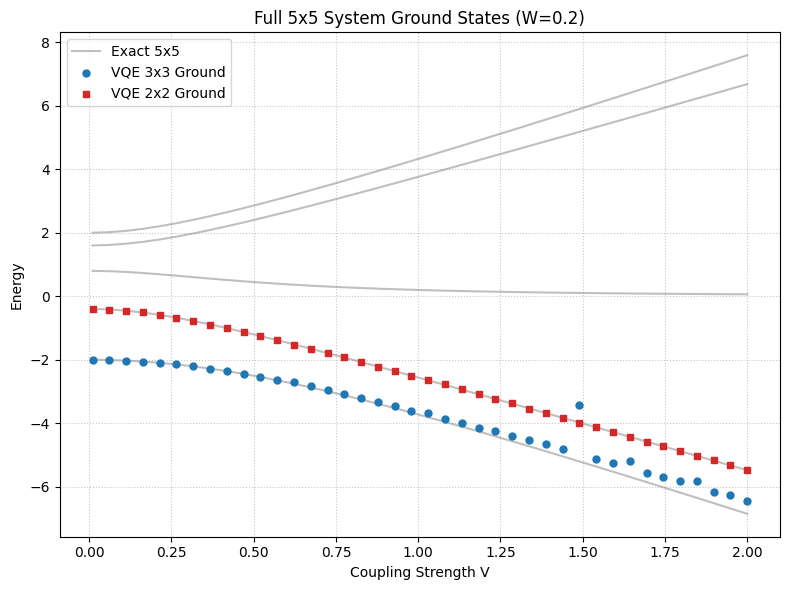

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import exercise3 as e3
import exercise5 as e5

eps = 1.0
W = 0.2
V_vals = np.linspace(0.01, 2.0, 40)  
shots = 10000

exact_energies = []
vqe_2x2_ground = []
vqe_3x3_ground = []

for V in V_vals:
    H_5x5 = np.array([
        [-2*eps, 0, np.sqrt(6)*V, 0, 0],
        [0, -eps+3*W, 0, 3*V, 0],
        [np.sqrt(6)*V, 0, 4*W, 0, np.sqrt(6)*V],
        [0, 3*V, 0, eps+3*W, 0],
        [0, 0, np.sqrt(6)*V, 0, 2*eps]
    ])
    evals = np.sort(np.linalg.eigvalsh(H_5x5))
    exact_energies.append(evals)

    coeffs_2x2 = {
        "I": 3*W,
        "Z": -eps,
        "X": 3*V
    }
    init_angles_2 = np.random.uniform(0, 2*np.pi, 3)
    vqe_2 = e3.AdamOptimizerVQE(shots=shots, coeffs=coeffs_2x2)
    res_2_g = vqe_2.optimize_Adam(init_angles_2)
    vqe_2x2_ground.append(res_2_g["energy"])

    coeffs_3x3 = {
        "I": 2*W,
        "ZI": -eps,
        "IZ": -2*W,
        "ZZ": -eps,
        "IX": (np.sqrt(6)/2) * V,
        "ZX": (np.sqrt(6)/2) * V,
        "XX": (np.sqrt(6)/2) * V,
        "YY": (np.sqrt(6)/2) * V
    }
    init_angles_3 = np.random.uniform(0, 2*np.pi, 8)
    vqe_3 = e5.AdamOptimizerVQE_two_qubit(shots=shots, coeffs=coeffs_3x3)
    res_3_g = vqe_3.optimize_Adam(init_angles_3)
    vqe_3x3_ground.append(res_3_g["energy"])

exact_energies = np.array(exact_energies)

plt.figure(figsize=(8, 6))

for i in range(5):
    label = "Exact 5x5" if i == 0 else ""
    plt.plot(V_vals, exact_energies[:, i], linestyle='-', color='gray', alpha=0.5, label=label)

plt.scatter(V_vals, vqe_3x3_ground, color='tab:blue', s=25, label='VQE 3x3 Ground', zorder=3)
plt.scatter(V_vals, vqe_2x2_ground, color='tab:red', s=25, marker='s', label='VQE 2x2 Ground', zorder=3)

plt.title(f"Full 5x5 System Ground States (W={W})")
plt.xlabel("Coupling Strength V")
plt.ylabel("Energy")
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()